customers              -> (99441, 5)
geolocation            -> (1000163, 5)
order_items            -> (112650, 7)
order_payments         -> (103886, 5)
order_reviews          -> (99224, 7)
orders                 -> (99441, 8)
products               -> (32951, 9)
sellers                -> (3095, 4)
category_translation   -> (71, 2)
13 products have a category with no English translation
(112650, 35)
rows with negative delivery_days: 0
late orders: 6.6%


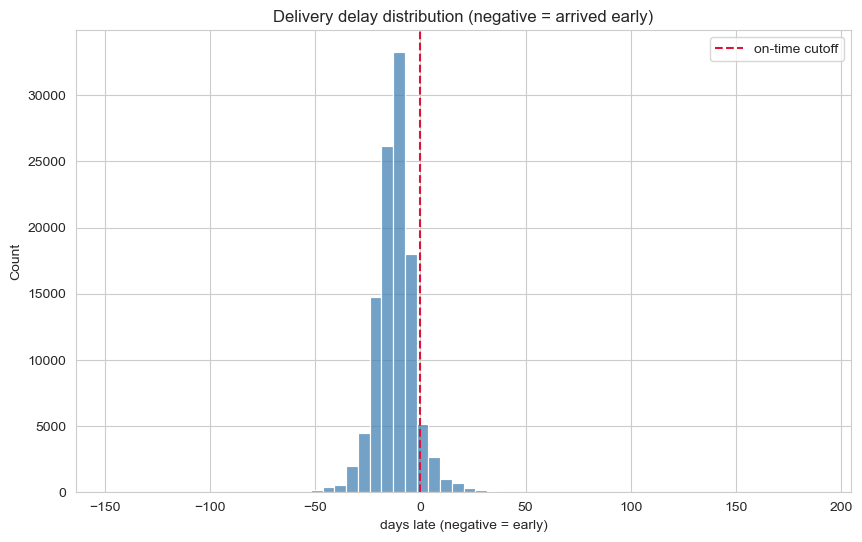

C:\Users\Afdal Hussain\AppData\Local\Temp\ipykernel_7644\3481933562.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=delivered, x="review_score", y="delivery_delay_days", ax=ax, showfliers=False, palette="coolwarm")


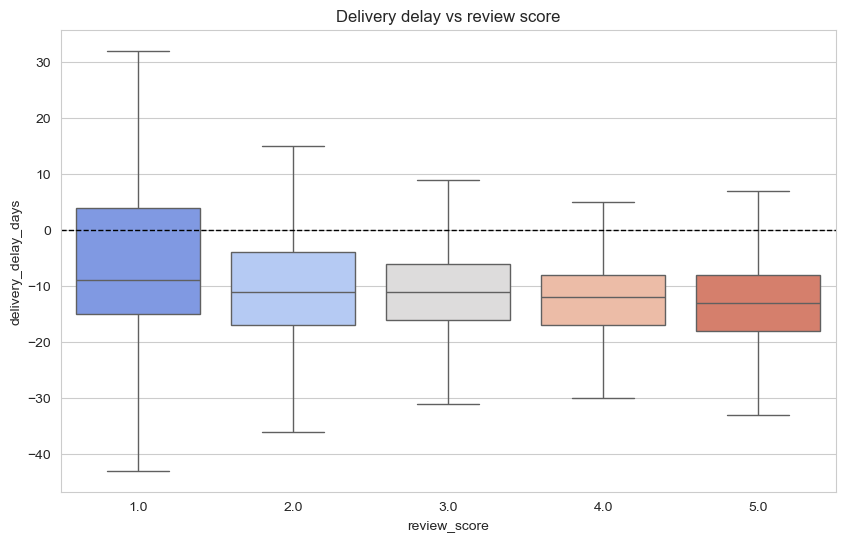

C:\Users\Afdal Hussain\AppData\Local\Temp\ipykernel_7644\3481933562.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.values, y=status_counts.index, ax=ax, palette="viridis")


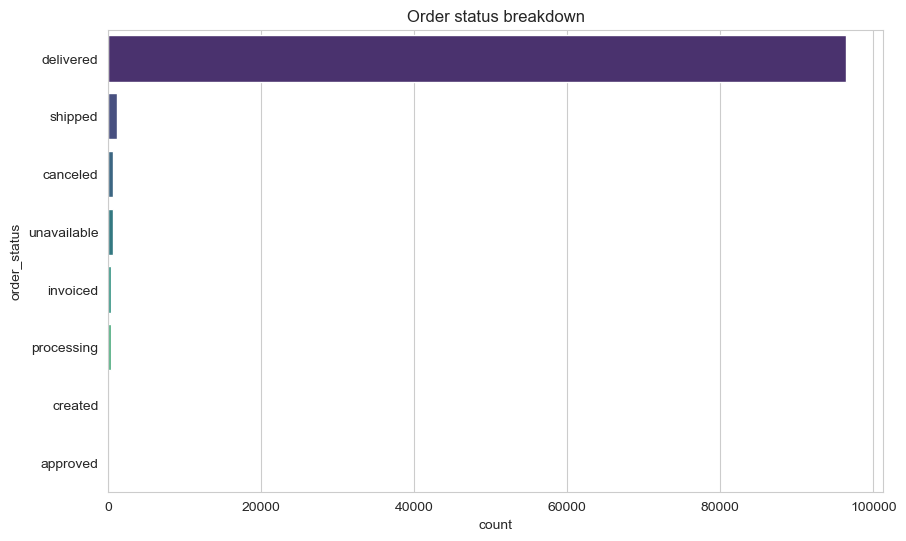

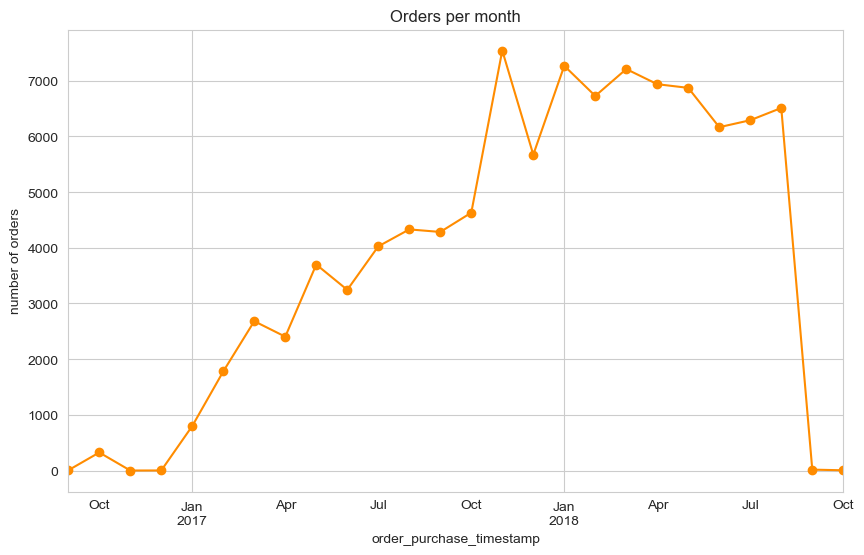

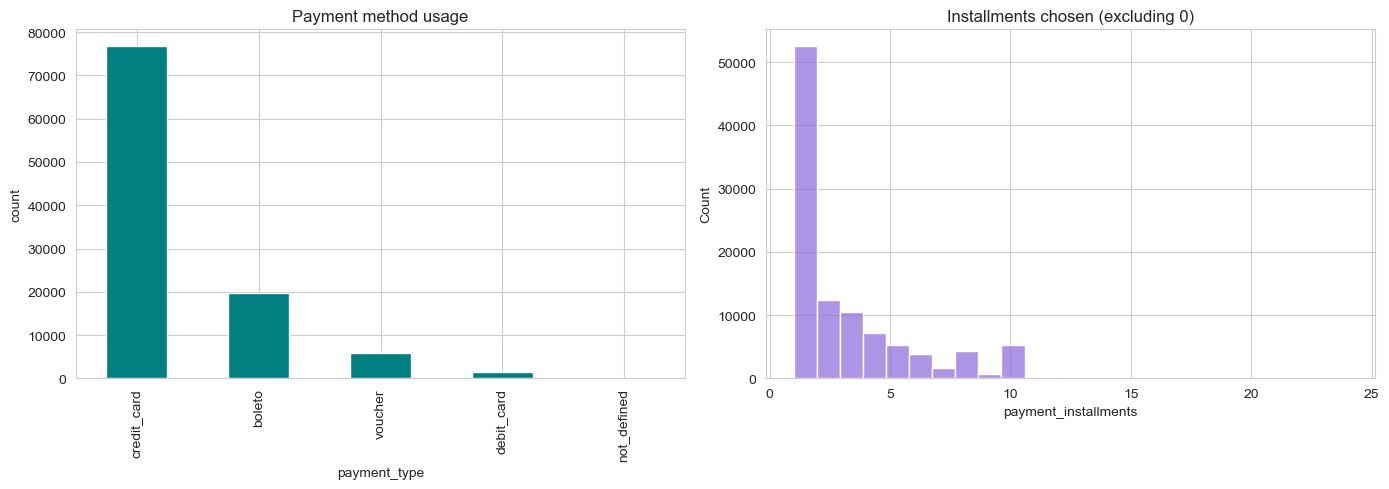

C:\Users\Afdal Hussain\AppData\Local\Temp\ipykernel_7644\3481933562.py:181: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.values, y=category_revenue.index, ax=ax, palette="mako")


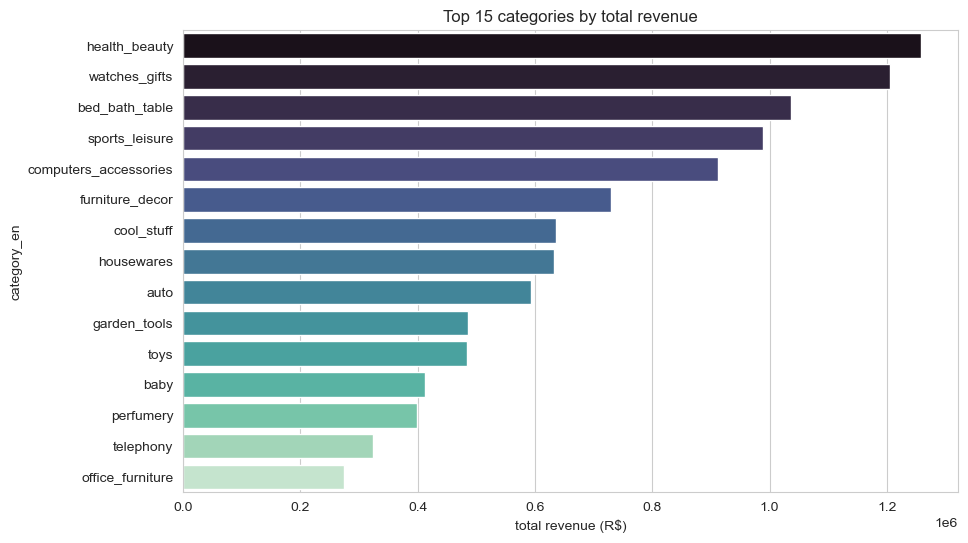

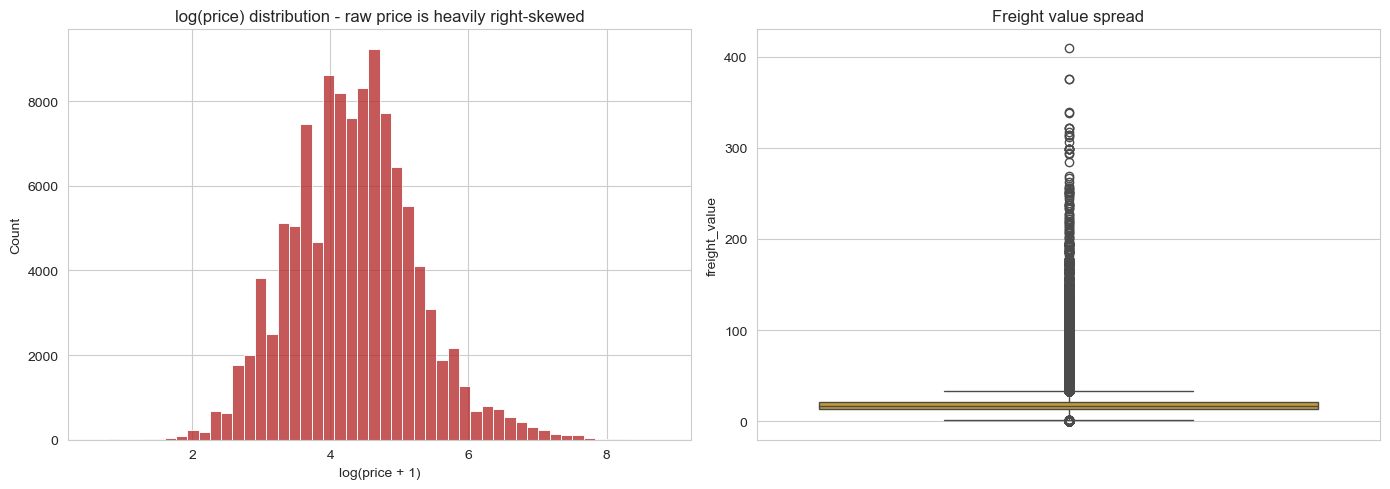

0.500      74.99
0.900     229.80
0.990     890.00
0.999    2110.00
Name: price, dtype: float64


C:\Users\Afdal Hussain\AppData\Local\Temp\ipykernel_7644\3481933562.py:204: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.values, y=state_counts.index, ax=ax, palette="rocket")


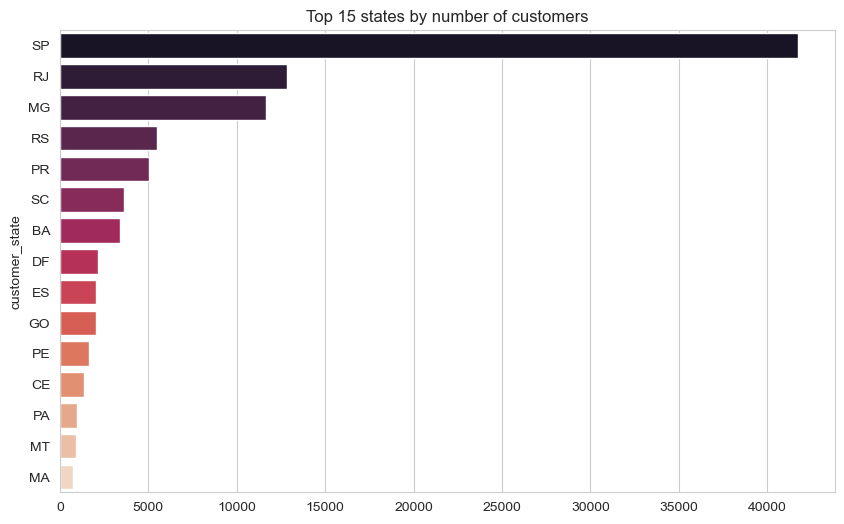

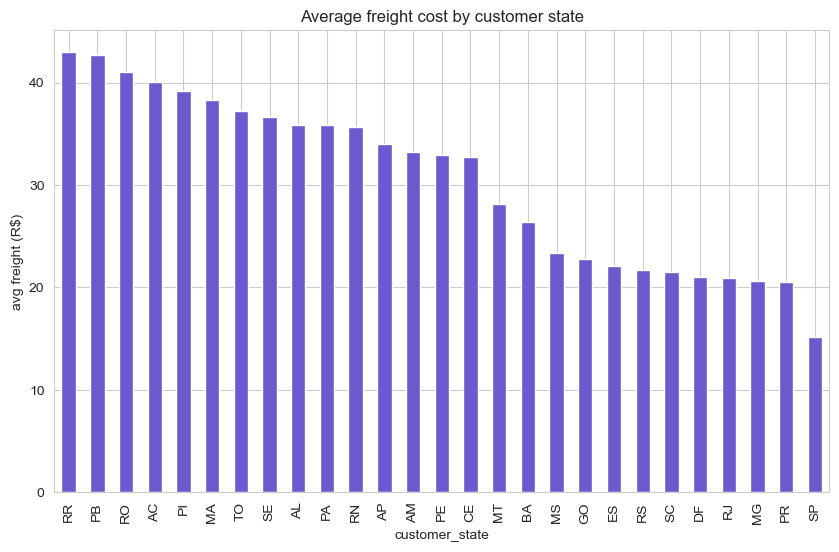

C:\Users\Afdal Hussain\AppData\Local\Temp\ipykernel_7644\3481933562.py:221: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=order_reviews, x="review_score", palette="coolwarm", ax=ax)


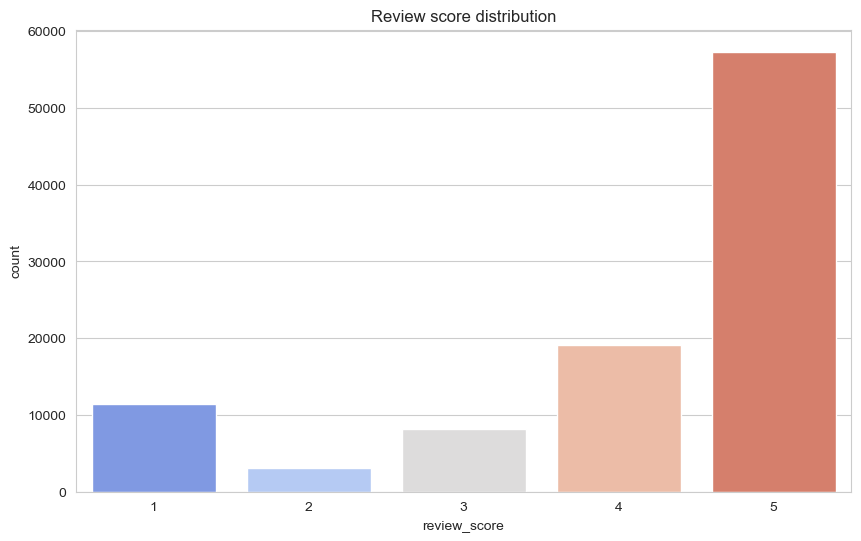

worst-rated categories (min 100 reviews):
                           mean  count
category_en                           
office_furniture       3.491950   1677
fashion_male_clothing  3.641221    131
fixed_telephony        3.681992    261
home_confort           3.831019    432
audio                  3.833333    360

best-rated categories (min 100 reviews):
                            mean  count
category_en                            
fashion_shoes           4.228682    258
food_drink              4.310469    277
luggage_accessories     4.315257   1088
books_technical         4.363636    264
books_general_interest  4.446266    549


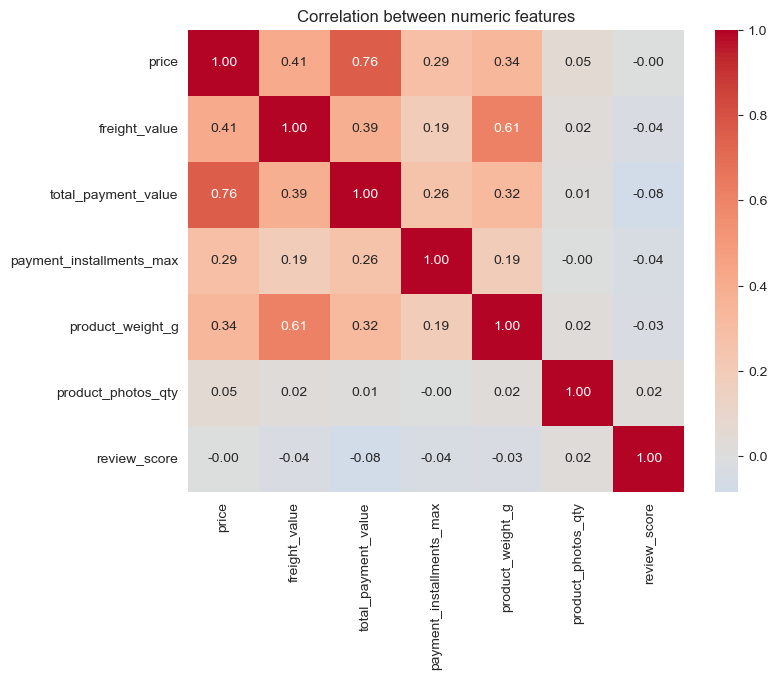

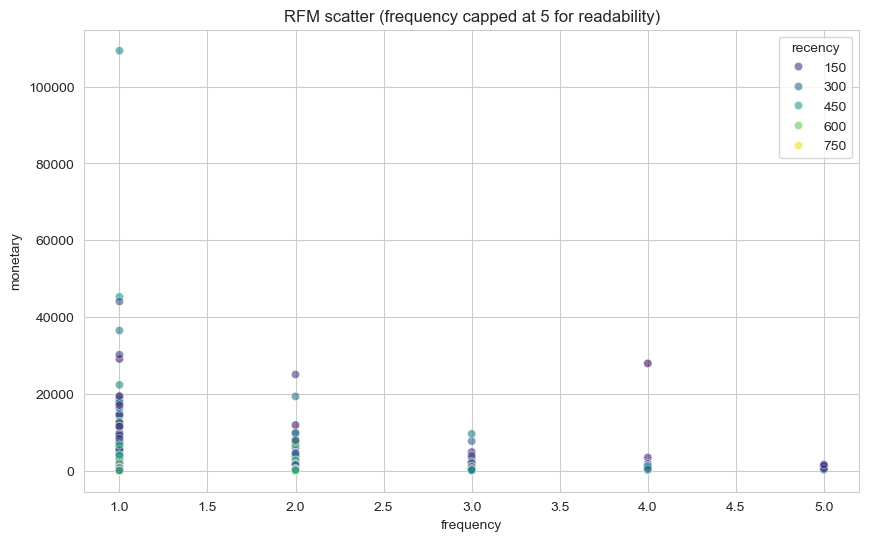

share of one-time customers: 96.9%


In [1]:

#Olist E-Commerce EDA
#Analysing the Olist Brazilian e-commerce dataset (~100k orders, 2016-2018) to practice some proper EDA.

#Trying to answer real questions: delivery performance, what drives review scores, where the revenue's coming from.
# Dataset: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 50)

DATA_PATH = Path(r"C:\Users\Afdal Hussain\Desktop\Python Projects\Datasets\E-Commerce_Dataset")

customers = pd.read_csv(DATA_PATH / "olist_customers_dataset.csv")
geolocation = pd.read_csv(DATA_PATH / "olist_geolocation_dataset.csv")
order_items = pd.read_csv(DATA_PATH / "olist_order_items_dataset.csv")
order_payments = pd.read_csv(DATA_PATH / "olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(DATA_PATH / "olist_order_reviews_dataset.csv")
orders = pd.read_csv(DATA_PATH / "olist_orders_dataset.csv")
products = pd.read_csv(DATA_PATH / "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_PATH / "olist_sellers_dataset.csv")
category_translation = pd.read_csv(DATA_PATH / "product_category_name_translation.csv")

#quick check to make sure nothing loaded empty and my paths are right
tables = {
    "customers": customers, "geolocation": geolocation, "order_items": order_items,
    "order_payments": order_payments, "order_reviews": order_reviews, "orders": orders,
    "products": products, "sellers": sellers, "category_translation": category_translation,
}
for name, df in tables.items():
    print(f"{name:22s} -> {df.shape}")


orders.head(3)


customers.head(3)


#A few things need sorting before any real analysis:
#category names are in Portuguese -> map to English
#date columns are just strings right now -> convert to datetime
#payments and reviews are one-to-many with orders -> aggregate before merging, or I'll duplicate rows


products = products.merge(category_translation, on="product_category_name", how="left")
products.rename(columns={"product_category_name_english": "category_en"}, inplace=True)

#a handful of categories didn't have an English translation in the mapping file so im patching those
missing_cat = products["category_en"].isna() & products["product_category_name"].notna()
print(f"{missing_cat.sum()} products have a category with no English translation")
products.loc[missing_cat, "category_en"] = products.loc[missing_cat, "product_category_name"]

date_cols = [
    "order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
    "order_delivered_customer_date", "order_estimated_delivery_date",
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

order_reviews["review_creation_date"] = pd.to_datetime(order_reviews["review_creation_date"])
order_reviews["review_answer_timestamp"] = pd.to_datetime(order_reviews["review_answer_timestamp"])

orders[date_cols].dtypes

#payments can have multiple rows per order (installments, vouchers, etc). Aggregate first
payments_agg = order_payments.groupby("order_id").agg(
    total_payment_value=("payment_value", "sum"),
    payment_installments_max=("payment_installments", "max"),
    payment_type_main=("payment_type", lambda x: x.mode().iat[0] if not x.mode().empty else np.nan),
).reset_index()

#some orders have more than one review so im keep the most recent one
reviews_dedup = (
    order_reviews.sort_values("review_answer_timestamp")
    .drop_duplicates("order_id", keep="last")[["order_id", "review_score", "review_comment_message"]]
)

master = (
    order_items
    .merge(products, on="product_id", how="left")
    .merge(sellers, on="seller_id", how="left")
    .merge(orders, on="order_id", how="left")
    .merge(customers, on="customer_id", how="left")
    .merge(payments_agg, on="order_id", how="left")
    .merge(reviews_dedup, on="order_id", how="left")
)

print(master.shape)
master.head(3)


#missing data check
missing_pct = (master.isna().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]


#review_score is missing where there's no matching review, and delivery date columns will be null for orders that never got delivered (cancelled, in transit, etc). Not blanket-filling any of this, just filtering appropriately per section below.

# This is what I actually care about most. does Olist deliver on time, and does it matter?


delivered = master[master["order_status"] == "delivered"].copy()

delivered["delivery_days"] = (delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"]).dt.days
delivered["estimated_days"] = (delivered["order_estimated_delivery_date"] - delivered["order_purchase_timestamp"]).dt.days
delivered["delivery_delay_days"] = (delivered["order_delivered_customer_date"] - delivered["order_estimated_delivery_date"]).dt.days
delivered["is_late"] = delivered["delivery_delay_days"] > 0


print("rows with negative delivery_days:", (delivered["delivery_days"] < 0).sum())
print(f"late orders: {delivered['is_late'].mean():.1%}")
delivered["delivery_delay_days"].describe()


fig, ax = plt.subplots()
sns.histplot(delivered["delivery_delay_days"], bins=60, ax=ax, color="steelblue")
ax.axvline(0, color="crimson", linestyle="--", label="on-time cutoff")
ax.set_title("Delivery delay distribution (negative = arrived early)")
ax.set_xlabel("days late (negative = early)")
ax.legend()
plt.show()


fig, ax = plt.subplots()
sns.boxplot(data=delivered, x="review_score", y="delivery_delay_days", ax=ax, showfliers=False, palette="coolwarm")
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Delivery delay vs review score")
plt.show()

delivered.groupby("review_score")["is_late"].mean().rename("pct_late")

status_counts = orders["order_status"].value_counts()

fig, ax = plt.subplots()
sns.barplot(x=status_counts.values, y=status_counts.index, ax=ax, palette="viridis")
ax.set_title("Order status breakdown")
ax.set_xlabel("count")
plt.show()

status_counts


monthly_orders = orders.set_index("order_purchase_timestamp").resample("ME").size()

fig, ax = plt.subplots()
monthly_orders.plot(ax=ax, marker="o", color="darkorange")
ax.set_title("Orders per month")
ax.set_ylabel("number of orders")
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_payments["payment_type"].value_counts().plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Payment method usage")
axes[0].set_ylabel("count")

sns.histplot(order_payments.loc[order_payments["payment_installments"] > 0, "payment_installments"],
             bins=24, ax=axes[1], color="mediumpurple")
axes[1].set_title("Installments chosen (excluding 0)")

plt.tight_layout()
plt.show()


category_revenue = (
    master.groupby("category_en")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots()
sns.barplot(x=category_revenue.values, y=category_revenue.index, ax=ax, palette="mako")
ax.set_title("Top 15 categories by total revenue")
ax.set_xlabel("total revenue (R$)")
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(np.log1p(master["price"]), bins=50, ax=axes[0], color="firebrick")
axes[0].set_title("log(price) distribution - raw price is heavily right-skewed")
axes[0].set_xlabel("log(price + 1)")

sns.boxplot(y=master["freight_value"], ax=axes[1], color="goldenrod")
axes[1].set_title("Freight value spread")

plt.tight_layout()
plt.show()

print(master["price"].quantile([0.5, 0.9, 0.99, 0.999]))

state_counts = customers["customer_state"].value_counts().head(15)

fig, ax = plt.subplots()
sns.barplot(x=state_counts.values, y=state_counts.index, ax=ax, palette="rocket")
ax.set_title("Top 15 states by number of customers")
plt.show()


freight_by_state = master.groupby("customer_state")["freight_value"].mean().sort_values(ascending=False)

fig, ax = plt.subplots()
freight_by_state.plot(kind="bar", ax=ax, color="slateblue")
ax.set_title("Average freight cost by customer state")
ax.set_ylabel("avg freight (R$)")
plt.show()

freight_by_state.head(5)


fig, ax = plt.subplots()
sns.countplot(data=order_reviews, x="review_score", palette="coolwarm", ax=ax)
ax.set_title("Review score distribution")
plt.show()


cat_reviews = master.groupby("category_en")["review_score"].agg(["mean", "count"])
cat_reviews = cat_reviews[cat_reviews["count"] > 100].sort_values("mean")

print("worst-rated categories (min 100 reviews):")
print(cat_reviews.head(5))
print("\nbest-rated categories (min 100 reviews):")
print(cat_reviews.tail(5))


numeric_cols = [
    "price", "freight_value", "total_payment_value", "payment_installments_max",
    "product_weight_g", "product_photos_qty", "review_score",
]

corr = master[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric features")
plt.show()


snapshot_date = orders["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = master.groupby("customer_unique_id").agg(
    recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("total_payment_value", "sum"),
).reset_index()

rfm.describe()

# %%
fig, ax = plt.subplots()
sns.scatterplot(data=rfm[rfm["frequency"] <= 5], x="frequency", y="monetary", hue="recency",
                 palette="viridis", alpha=0.6, ax=ax)
ax.set_title("RFM scatter (frequency capped at 5 for readability)")
plt.show()

print(f"share of one-time customers: {(rfm['frequency'] == 1).mean():.1%}")


#Key takeaways
#Late delivery is the clearest driver of bad reviews. Late rate roughly triples going from 5-star down to 1-star reviews.
#Estimates are conservative. Most orders arrive earlier than promised, probably why the late-delivery effect isn't even worse.
#Revenue is a long tail which means a handful of categories drive a disproportionate share.
#Geography = shipping cost (customers far from the SP/RJ hub pay more in freight)
#Retention is a real problem, the overwhelming majority of customers only order once.

#Potential next steps
#Map delivery delay by lat/lng using the geolocation table
#Build a simple churn / one-time-buyer classifier off the RFM features
#Run basic NLP on review_comment_message to see what people actually complain about